# abl2 — MobileViT-S with Entropy-Guided Spatial Gate

Builds directly on the MobileViT-S baseline from `34_27100095.ipynb` (91.46 % val acc, 308 img/s).  
ImageNet-1K pretrained weights are loaded from timm (`pretrained=True`). A head-only warmup phase
(5 epochs, frozen backbone) reproduces the baseline fine-tune before the gate is installed.

**What this notebook does (in order):**
1. Explore MobileViT-S architecture — exact layer names, tensor shapes, parameter counts
2. Load pretrained weights, run head warmup on ImageNet-100, verify baseline accuracy
3. Implement the entropy-guided spatial gate and install it into the MobileViT blocks in-place
4. Verify gated model at `keep_ratio=1.0` exactly matches the baseline (identity check)
5. Train the gated model with keep_ratio < 1.0 and compare throughput vs accuracy

In [23]:
import time
import json
import types
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader

import timm
from timm.data import resolve_model_data_config, create_transform

from datasets import load_dataset
from tqdm.auto import tqdm

import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

assert torch.cuda.is_available(), 'CUDA not available'
DEVICE = torch.device('cuda')
print(f'Device : {DEVICE}  ({torch.cuda.get_device_name(0)})')
print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
print(f'timm   : {timm.__version__}')

Device : cuda  (Tesla T4)
VRAM   : 15.6 GB
timm   : 1.0.25


In [24]:
CFG = {
    'num_classes'     : 100,
    'warmup_epochs'   : 5,     # head-only phase (frozen backbone) — mirrors baseline
    'gate_epochs'     : 5,     # full fine-tune phase with gate installed
    'batch_size'      : 128,
    'num_workers'     : 8,
    'warmup_lr'       : 1e-3,  # head-only LR — same as baseline
    'gate_lr'         : 1e-4,  # full model LR after gate is installed
    'weight_decay'    : 0.05,
    'grad_clip'       : 1.0,
    'label_smoothing' : 0.1,
    'amp'             : True,
    'checkpoint_dir'  : Path('checkpoints'),
    'seed'            : 42,
    'keep_ratio'      : 0.5,   # fraction of patches forwarded through full attention
    'BASELINE_ACC'    : 91.46, # from baseline notebook (34_27100095.ipynb)
    'BASELINE_TPUT'   : 308,   # img/s from baseline notebook
}

CFG['checkpoint_dir'].mkdir(exist_ok=True)
torch.manual_seed(CFG['seed'])
torch.cuda.manual_seed(CFG['seed'])

## MobileViT-S Architecture

### High-level structure

```
Input  3×256×256
  │
  ├─ stem          Conv2d(3→16, 3×3, stride=2) + BN + SiLU          → 16×128×128
  ├─ stages[0]     MV2Block(16→16, stride=1)                         → 16×128×128
  ├─ stages[1]     MV2Block(16→24, stride=2) × 3                     → 24×64×64
  ├─ stages[2]     MV2Block(24→48, stride=2)
  │                MobileViTBlock(C=48, d=144, L=2, P=2)             → 48×32×32
  ├─ stages[3]     MV2Block(48→64, stride=2)
  │                MobileViTBlock(C=64, d=192, L=4, P=2)             → 64×16×16
  ├─ stages[4]     MV2Block(64→80, stride=2)
  │                MobileViTBlock(C=80, d=240, L=3, P=2)             → 80×8×8
  ├─ final_conv    Conv2d(80→320, 1×1) + BN + SiLU                   → 320×8×8
  └─ head          GlobalAvgPool → Linear(320, 100)
```

**C** = number of input/output channels at that stage  
**d** = transformer projection dimension (hidden dim inside the block)  
**L** = number of transformer layers inside the block  
**P** = patch size (2×2 → each patch covers a 2×2 spatial region)

### MV2 Block (MobileNetV2 inverted residual)

```
x → Conv(1×1, expand) → DWConv(3×3) → Conv(1×1, project) → (+x if same shape)
```
Expansion ratio = 4. BN + SiLU throughout. Residual only when stride=1 and C_in=C_out.

### MobileViT Block — the insertion target

This is where our gate goes. Full forward pass:

```
x  (B, C, H, W)
 │
 ├─ conv_kxk   Conv(C→C, 3×3) + BN + SiLU     local feature extraction
 ├─ conv_1x1   Conv(C→d, 1×1) + BN + SiLU     project up to transformer dim
 │
 │   ◄── ENTROPY GATE INSERTED HERE ──►
 │   Score each of the N = (H/P)×(W/P) patches by entropy of their d-dim vectors.
 │   Keep top-k patches (lowest entropy = most structured / feature-rich).
 │   Zero out unselected positions before transformer.
 │
 ├─ unfold     (B,d,H,W) → (B·P²,N,d)         group same-position tokens globally
 ├─ transformer L × (MHSA + FFN + LayerNorm)   global self-attention
 ├─ norm       LayerNorm
 ├─ fold       (B·P²,N,d) → (B,d,H,W)         restore spatial layout
 ├─ conv_proj  Conv(d→C, 1×1) + BN + SiLU     project back to C
 └─ conv_fusion Conv(2C→C, 1×1) + BN + SiLU   fuse with pre-block input x
```

**Why gate here?** After `conv_1x1` the tensor is `B×d×H×W` — each `1×d` vector at position `(i,j)` is the
feature representation of that spatial location in transformer space. Entropy of this vector tells us whether
this position activates a *specific subset* of the d channels (low entropy = salient) or all channels equally
(high entropy = background / noise). We gate at patch granularity because the transformer's unfolding groups
tokens by local patch position — gating a full patch is structurally clean.

### Unfolding explained

MobileViT does NOT flatten H×W into N tokens like a standard ViT. Instead with patch size P:
- Divide the H×W map into `(H/P)×(W/P)` non-overlapping P×P patches → N patches total
- For each of the P²=4 local positions within a patch, collect the same position from ALL patches → a sequence of length N
- Run transformer on each of the P² sequences independently (or interleaved)

This gives each token **global context** (it sees the same local position in every patch) while keeping
sequence length at N instead of H×W. For stage 2 (32×32, P=2): N=256, P²=4, sequences of length 256.

### Loss function

Same as baseline: `CrossEntropyLoss(label_smoothing=0.1)` + AdamW(weight_decay=0.05).
The gate adds no new parameters — it is a deterministic, differentiable scoring function applied at inference.

In [25]:
# Load model and print full leaf level architecture layers
ref = timm.create_model('mobilevit_s', pretrained=False, num_classes=CFG['num_classes'])

print(f'Total params : {sum(p.numel() for p in ref.parameters())/1e6:.3f}M')
print(f'Trainable    : {sum(p.numel() for p in ref.parameters() if p.requires_grad)/1e6:.3f}M')
print()
print(f'{"Layer name":<65} {"Type":<28} {"Params":>10}')
print('-' * 106)
for name, m in ref.named_modules():
    if not list(m.children()):   # leaf nodes only
        n = sum(p.numel() for p in m.parameters())
        if n > 0 or isinstance(m, (nn.ReLU, nn.SiLU, nn.GELU, nn.BatchNorm2d, nn.LayerNorm)):
            print(f'{name:<65} {type(m).__name__:<28} {n:>10,}')

Total params : 5.002M
Trainable    : 5.002M

Layer name                                                        Type                             Params
----------------------------------------------------------------------------------------------------------
stem.conv                                                         Conv2d                              432
stem.bn.act                                                       SiLU                                  0
stages.0.0.conv1_1x1.conv                                         Conv2d                            1,024
stages.0.0.conv1_1x1.bn.act                                       SiLU                                  0
stages.0.0.conv2_kxk.conv                                         Conv2d                              576
stages.0.0.conv2_kxk.bn.act                                       SiLU                                  0
stages.0.0.conv3_1x1.conv                                         Conv2d                            2,048


In [26]:
# Forward-hook shape tracer
# Runs one dummy forward pass and records (input_shape, output_shape) for every named module. Particularly useful for seeing the tensor dimensions at each MobileViT block stage — these are the shapes the gate will operate on.

shapes = {}
hooks  = []

def _hook(name):
    def fn(m, inp, out):
        in_s = tuple(inp[0].shape) if isinstance(inp[0], torch.Tensor) else '?'
        out_s = tuple(out.shape)    if isinstance(out,    torch.Tensor) else '?'
        shapes[name] = (in_s, out_s)
    return fn

ref.eval()
for name, m in ref.named_modules():
    # only hook stages and direct sub-blocks to keep output clean
    if name in ('stem', 'final_conv') or name.startswith('stages') and name.count('.') <= 1:
        hooks.append(m.register_forward_hook(_hook(name)))

with torch.no_grad():
    ref(torch.randn(1, 3, 256, 256))

for h in hooks: h.remove()

print(f'{"Module":<40} {"Input shape":<30} {"Output shape"}')
print('-' * 90)
for name, (inp, out) in shapes.items():
    print(f'{name:<40} {str(inp):<30} {out}')

Module                                   Input shape                    Output shape
------------------------------------------------------------------------------------------
stem                                     (1, 3, 256, 256)               (1, 16, 128, 128)
stages.0                                 (1, 16, 128, 128)              (1, 32, 128, 128)
stages.1                                 (1, 32, 128, 128)              (1, 64, 64, 64)
stages.2                                 (1, 64, 64, 64)                (1, 96, 32, 32)
stages.3                                 (1, 96, 32, 32)                (1, 128, 16, 16)
stages.4                                 (1, 128, 16, 16)               (1, 160, 8, 8)
stages                                   (1, 16, 128, 128)              (1, 160, 8, 8)
final_conv                               (1, 160, 8, 8)                 (1, 640, 8, 8)


In [27]:
# MobileViT block inspection 
# Finds every MobileViTBlock in the model, reports its sub-module names/types and records input/output shapes via hooks. These are the exact attribute names we rely on in the gated forward pass below. derive block class from the live model — works across all timm versions

MobileViTBlock = type(next(m for _, m in ref.named_modules()
                            if hasattr(m, 'patch_size') and hasattr(m, 'transformer')))
print(f'MobileViT block class : {MobileViTBlock.__name__}')

mvit_blocks = [(n, m) for n, m in ref.named_modules() if isinstance(m, MobileViTBlock)]
print(f'Found {len(mvit_blocks)} MobileViTBlock(s):\n')

for bname, blk in mvit_blocks:
    print(f'  {bname}')
    print(f'    patch_size   : {blk.patch_size}')
    for cname, child in blk.named_children():
        n = sum(p.numel() for p in child.parameters())
        print(f'    .{cname:<20} {type(child).__name__:<30} {n:,} params')
    print()

# Hook each block to record in/out shapes
blk_shapes = {}
hooks = []
for bname, blk in mvit_blocks:
    def _bh(name):
        def fn(m, inp, out):
            blk_shapes[name] = {'in': tuple(inp[0].shape), 'out': tuple(out.shape)}
        return fn
    hooks.append(blk.register_forward_hook(_bh(bname)))

with torch.no_grad():
    ref(torch.randn(1, 3, 256, 256))
for h in hooks: h.remove()

print('Block tensor shapes (batch=1):')
for name, s in blk_shapes.items():
    B, C, H, W = s['in']
    ph, pw = dict(ref.named_modules())[name].patch_size
    N = (H // ph) * (W // pw)
    print(f'  {name:<35}  in={s["in"]}  out={s["out"]}  N_patches={N}')

MobileViT block class : MobileVitBlock
Found 3 MobileViTBlock(s):

  stages.2.1
    patch_size   : (2, 2)
    .conv_kxk             ConvNormAct                    83,136 params
    .conv_1x1             Conv2d                         13,824 params
    .transformer          Sequential                     334,944 params
    .norm                 LayerNorm                      288 params
    .conv_proj            ConvNormAct                    14,016 params
    .conv_fusion          ConvNormAct                    166,080 params

  stages.3.1
    patch_size   : (2, 2)
    .conv_kxk             ConvNormAct                    147,712 params
    .conv_1x1             Conv2d                         24,576 params
    .transformer          Sequential                     1,188,096 params
    .norm                 LayerNorm                      384 params
    .conv_proj            ConvNormAct                    24,832 params
    .conv_fusion          ConvNormAct                    295,168 params



## Dataset — ImageNet-100

Same split and transforms as the baseline notebook. Loaded from HuggingFace cache (already downloaded).

In [28]:
print('Loading ImageNet-100 ...')
hf_dataset = load_dataset('clane9/imagenet-100')
print(f"Train : {len(hf_dataset['train'])}   Val : {len(hf_dataset['validation'])}")

class HFImageDataset(torch.utils.data.Dataset):
    def __init__(self, hf_split, transform):
        self.data = hf_split
        self.transform = transform
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        s = self.data[idx]
        return self.transform(s['image'].convert('RGB')), s['label']


def build_loaders(model_cfg, batch_size, num_workers):
    train_transform = create_transform(**model_cfg, is_training=True)
    val_transform = create_transform(**model_cfg, is_training=False)
    train_loader = DataLoader(
        HFImageDataset(hf_dataset['train'],      train_transform),
        batch_size=batch_size, shuffle=True,
        num_workers=num_workers, pin_memory=True, drop_last=True, persistent_workers=True
    )
    val_loader = DataLoader(
        HFImageDataset(hf_dataset['validation'], val_transform),
        batch_size=batch_size * 2, shuffle=False,
        num_workers=num_workers, pin_memory=True, persistent_workers=True
    )
    return train_loader, val_loader


model_cfg   = resolve_model_data_config(ref)
INPUT_SIZE  = model_cfg['input_size'][1:]   # (256, 256)
train_loader, val_loader = build_loaders(model_cfg, CFG['batch_size'], CFG['num_workers'])
print(f'Input size : {INPUT_SIZE}')

Loading ImageNet-100 ...


Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/17 [00:00<?, ?it/s]

Train : 126689   Val : 5000
Input size : (256, 256)


In [29]:
# Training utilities
def train_one_epoch(model, loader, optimizer, criterion, scaler, epoch, epochs):
    model.train()
    total_loss, total = 0.0, 0
    pbar = tqdm(loader, desc=f'  Train {epoch+1}/{epochs}', leave=False, dynamic_ncols=True)
    for images, labels in pbar:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        optimizer.zero_grad()
        with torch.autocast('cuda', enabled=CFG['amp']):
            loss = criterion(model(images), labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), CFG['grad_clip'])
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * images.size(0)
        total += images.size(0)
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    return total_loss / total


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    for images, labels in loader:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        with torch.autocast('cuda', enabled=CFG['amp']):
            preds = model(images).argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return 100.0 * correct / total


@torch.no_grad()
def measure_throughput(model, input_size, batch_size=64, n_warmup=20, n_runs=100):
    model.eval()
    dummy = torch.randn(batch_size, 3, *input_size).to(DEVICE)
    for _ in range(n_warmup): model(dummy)
    torch.cuda.synchronize()
    t0 = time.perf_counter()
    for _ in range(n_runs): model(dummy)
    torch.cuda.synchronize()
    return (batch_size * n_runs) / (time.perf_counter() - t0)


print('Training utilities defined.')

Training utilities defined.


## Weight Loading & Head Warmup

The fine-tuned checkpoint no longer exists, so we load ImageNet-1K pretrained weights directly from timm
(`pretrained=True`) and reproduce the baseline's head-only warmup phase here.

**Why not re-run the baseline notebook?**
The baseline notebook's only output we need is a calibrated head for ImageNet-100. We can get that in
exactly the same way — frozen backbone, 5 epochs, LR=1e-3 — right here. The backbone weights are
identical (timm pretrained) and the fine-tuning protocol is identical, so the result should land at
~91.46%. We record that number and use it as our baseline for all comparisons.

**Phase 1 — Head warmup (backbone frozen):**  matches baseline exactly.  
**Phase 2 — Gate fine-tune (full model):**  gate installed, backbone unfrozen, LR=1e-4.

In [30]:
# Phase 1: load pretrained weights + head-only warmup
model = timm.create_model('mobilevit_s', pretrained=True, num_classes=CFG['num_classes'])
model = model.to(DEVICE)
print(f'Loaded mobilevit_s pretrained (ImageNet-1K), head replaced for {CFG["num_classes"]} classes.')
print(f'Parameters : {sum(p.numel() for p in model.parameters())/1e6:.3f}M')

# freeze backbone — only head trains in this phase (mirrors baseline notebook exactly)
for p in model.parameters():
    p.requires_grad = False
for name, p in model.named_parameters():
    if any(k in name for k in ('head', 'classifier', 'fc')):
        p.requires_grad = True

head_params = [p for p in model.parameters() if p.requires_grad]
print(f'Trainable  : {sum(p.numel() for p in head_params)/1e3:.1f}K (head only)')

Loaded mobilevit_s pretrained (ImageNet-1K), head replaced for 100 classes.
Parameters : 5.002M
Trainable  : 1516.3K (head only)


In [31]:
# Head warmup training loop
criterion = nn.CrossEntropyLoss(label_smoothing=CFG['label_smoothing'])
optimizer_w = optim.AdamW(head_params, lr=CFG['warmup_lr'], weight_decay=CFG['weight_decay'])
scaler_w = torch.amp.GradScaler('cuda', enabled=CFG['amp'])
warmup_ckpt = CFG['checkpoint_dir'] / 'mobilevit_s_warmup_best.pth'

best_warmup_acc = 0.0
for epoch in range(CFG['warmup_epochs']):
    t0 = time.time()
    train_loss = train_one_epoch(model, train_loader, optimizer_w, criterion,
                                 scaler_w, epoch, CFG['warmup_epochs'])
    val_acc    = evaluate(model, val_loader)
    if val_acc > best_warmup_acc:
        best_warmup_acc = val_acc
        torch.save(model.state_dict(), warmup_ckpt)
    print(f'Warmup [{epoch+1}/{CFG["warmup_epochs"]}]  '
          f'loss={train_loss:.4f}  val={val_acc:.2f}%  best={best_warmup_acc:.2f}%  '
          f'({time.time()-t0:.1f}s)')

# reload best warmup checkpoint for gate phase
model.load_state_dict(torch.load(warmup_ckpt, map_location='cpu', weights_only=True))
baseline_acc = best_warmup_acc
print(f'\nHead warmup complete. Best val acc : {baseline_acc:.2f}%')
print(f'Expected (from baseline notebook)  : {CFG["BASELINE_ACC"]:.2f}%')

  Train 1/5:   0%|          | 0/989 [00:00<?, ?it/s]

Warmup [1/5]  loss=1.4553  val=90.40%  best=90.40%  (463.7s)


  Train 2/5:   0%|          | 0/989 [00:00<?, ?it/s]

Warmup [2/5]  loss=1.2211  val=91.26%  best=91.26%  (463.6s)


  Train 3/5:   0%|          | 0/989 [00:00<?, ?it/s]

Warmup [3/5]  loss=1.1926  val=90.56%  best=91.26%  (464.8s)


  Train 4/5:   0%|          | 0/989 [00:00<?, ?it/s]

Warmup [4/5]  loss=1.1840  val=91.46%  best=91.46%  (469.1s)


  Train 5/5:   0%|          | 0/989 [00:00<?, ?it/s]

Warmup [5/5]  loss=1.1709  val=91.64%  best=91.64%  (465.8s)

Head warmup complete. Best val acc : 91.64%
Expected (from baseline notebook)  : 91.46%


## Entropy-Guided Spatial Gate

### Design

The gate is installed into each `MobileViTBlock` by replacing its `forward` method in-place.  
**No new parameters are added.** All pretrained weights stay untouched.

**Gate forward pass (inside MobileViTBlock):**

```
x  (B, C, H, W)

1. y = conv_kxk(x)                           (B, C, H, W)
2. y = conv_1x1(y)                           (B, d, H, W)

3. ENTROPY SCORING
   - For each of the H*W positions, compute normalised Shannon entropy of the d-dim vector
   - Average entropy within each P×P patch → (B, N_h, N_w) patch scores
   - Select top-k patches (lowest entropy = most concentrated = most salient)
   - Build binary mask M ∈ {0,1}^(B, N)  where N = N_h × N_w

4. UNFOLD  (B, d, H, W) → (B·P², N, d)      MobileViT inter-patch grouping
5. MASK    zero out unselected patch positions within each sequence
6. TRANSFORMER  L × (MHSA + FFN + LN)       full attention only on kept tokens
7. NORM    LayerNorm
8. FOLD    (B·P², N, d) → (B, d, H, W)

9. y = conv_proj(y)                          (B, C, H, W)
10. y = conv_fusion(cat([x, y], dim=1))      (B, C, H, W)   fuse with pre-block x
```

### Unfold / Fold

MobileViT groups the H×W positions by their *local position within a patch*.  
For patch size P=2 and feature map H×W=32×32:
- N = (32/2)×(32/2) = 256 patches
- P²=4 local positions per patch
- 4 independent sequences, each of length 256

The unfold permutation: `(B, d, H, W) → (B, d, N_h, P, N_w, P) → (B·P², N, d)`

### Masking within unfolded sequences

After unfolding, each patch `n` appears once in each of the P² sequences at position `n`.  
Gate mask `M` (B, N) → expanded to (B·P², N, 1) → multiply `y` element-wise.  
Zeroed positions still flow through the transformer (no sparse kernel needed) but contribute zero
to the attention values. The residual connection in `conv_fusion` carries the original `x` through
unchanged for all positions, so masked positions are not dropped — they fall back to their
pre-block representation.

In [32]:
# Entropy utility
def entropy_scores(x):
    # normalised shannon entropy for each row of (H*W,channels) float tensor. Returns the importance weights tensor (H*W, ) in range [0,1] where low entropy means more structured features and high entropy means a more noisy/less useful token
    x = x.abs().float() + 1e-8
    p = x / x.sum(dim=1, keepdim=True)
    H = -(p * p.log()).sum(dim=1)
    H_max = torch.log(torch.tensor(x.shape[1], dtype=torch.float32, device=x.device))
    return H / (H_max + 1e-8)   # (N,)

In [36]:
# Scatter-gather gated MobileViT forward 
#
# Compute flow:
#   ALL tokens  -> entropy scoring        O(N·d)     cheap gate
#   TOP-k only  -> transformer            O(k²·d)    expensive op, now on k < N
#   BOTTOM-(N-k)-> conv_1x1 proj passthrough O(0)    hard residual — no BN pollution
#   ALL tokens  -> conv_fusion(cat[x,y])  O(N·C)     x is pre-block MV2 repr
#
# Unselected positions carry their conv_1x1 projection forward unchanged.
# y_out is initialised from y (not zeros), so scatter only overwrites selected
# positions — giving a true content-preserving bypass, not a learned soft gate.

def _unfold(x, patch_size):
    # (B, d, H, W) -> (B·P², N, d)  where N = (H/ph)·(W/pw)
    B, d, H, W = x.shape
    ph, pw = patch_size
    nph, npw = H // ph, W // pw
    x = x.reshape(B, d, nph, ph, npw, pw)
    x = x.permute(0, 3, 5, 2, 4, 1).contiguous()
    x = x.reshape(B * ph * pw, nph * npw, d)
    return x


def _fold(x, patch_size, H, W):
    # (B·P², N, d) -> (B, d, H, W)
    ph, pw = patch_size
    nph, npw = H // ph, W // pw
    B_pp, N, d = x.shape
    B = B_pp // (ph * pw)
    x = x.reshape(B, ph, pw, nph, npw, d)
    x = x.permute(0, 5, 3, 1, 4, 2).contiguous()
    x = x.reshape(B, d, H, W)
    return x


def _make_gated_forward(keep_ratio):
    def forward(self, x):
        # Local CNN representation (unchanged)
        y = self.conv_kxk(x)
        y = self.conv_1x1(y)                            # (B, d, H, W)
        B, d, H, W = y.shape
        ph, pw = self.patch_size
        nph, npw = H // ph, W // pw
        N = nph * npw
        pp = ph * pw

        # Entropy gate: score patches, select top-k
        if keep_ratio < 1.0:
            y_flat = y.permute(0, 2, 3, 1).reshape(B * H * W, d)
            ent_pix = entropy_scores(y_flat).reshape(B, H, W)
            ent_pat = ent_pix.reshape(B, nph, ph, npw, pw).mean(dim=(2, 4))
            ent_pat = ent_pat.reshape(B, N)
            k = max(1, int(N * keep_ratio))
            _, top_idx = ent_pat.topk(k, dim=1, largest=False)        # (B, k)

        # Unfold -> scatter-gather -> transformer -> scatter back
        y = _unfold(y, self.patch_size)                 # (B·P², N, d)

        if keep_ratio < 1.0:
            top_idx_exp = (top_idx.unsqueeze(1).expand(B, pp, k).reshape(B * pp, k).unsqueeze(-1).expand(B * pp, k, d))
            y_kept = torch.gather(y, 1, top_idx_exp)                  # (B·P², k, d)
            y_kept = self.transformer(y_kept)                          # O(k²·d)
            y_kept = self.norm(y_kept)

            # y_out starts from y so unselected tokens keep their conv_1x1 projection.
            # Cast y_kept to y_out.dtype: LayerNorm always outputs float32 under AMP
            # while y (conv output) is float16 — scatter_ requires matching dtypes.
            y_out = y.clone()
            y_out.scatter_(1, top_idx_exp, y_kept.to(y_out.dtype))
        else:
            y_out = self.norm(self.transformer(y))

        # Fold + project + fuse
        y = _fold(y_out, self.patch_size, H, W)
        y = self.conv_proj(y)
        y = self.conv_fusion(torch.cat([x, y], dim=1))
        return y

    return forward


def install_entropy_gate(model, keep_ratio):
    # replaces forward on every MobileViTBlock in-place, no weight copy
    MobileViTBlock = type(next(m for _, m in model.named_modules()
                                if hasattr(m, 'patch_size') and hasattr(m, 'transformer')))
    gated_fwd = _make_gated_forward(keep_ratio)
    patched = []
    for name, m in model.named_modules():
        if isinstance(m, MobileViTBlock):
            m.forward = types.MethodType(gated_fwd, m)
            m.keep_ratio = keep_ratio
            patched.append(name)
    return patched


print('Scatter-gather gate defined.')

Scatter-gather gate defined.


In [37]:
# Identity check: gated model at keep_ratio=1.0 must match original
# If this passes the gate is wired correctly before we change keep_ratio.

patched = install_entropy_gate(model, keep_ratio=1.0)
print(f'Patched blocks : {patched}')

gated_acc_full = evaluate(model, val_loader)
print(f'Gated model (keep_ratio=1.0) val acc : {gated_acc_full:.2f}%')
print(f'Baseline                              : {baseline_acc:.2f}%')
assert abs(gated_acc_full - baseline_acc) < 0.05, \
    'Identity check failed — forward pass mismatch, check unfold/fold implementation'
print('Identity check PASSED.')

Patched blocks : ['stages.2.1', 'stages.3.1', 'stages.4.1']
Gated model (keep_ratio=1.0) val acc : 91.64%
Baseline                              : 91.64%
Identity check PASSED.


In [38]:
# Evaluate gated model at target keep_ratio (no fine-tuning yet)
# Measures the zero-shot accuracy drop from gating before any adaptation training.
# Expected: some drop — the gate makes hard decisions the backbone wasn't trained for.

patched = install_entropy_gate(model, keep_ratio=CFG['keep_ratio'])
MobileViTBlock = type(next(m for _, m in model.named_modules()
                            if hasattr(m, 'patch_size') and hasattr(m, 'transformer')))
print(f'Gate installed at keep_ratio={CFG["keep_ratio"]}  (patches per block kept):')
for name, m in model.named_modules():
    if isinstance(m, MobileViTBlock):
        B, C, H, W = blk_shapes[name]['in']
        ph, pw = m.patch_size
        N = (H // ph) * (W // pw)
        k = max(1, int(N * CFG['keep_ratio']))
        print(f'  {name:<35}  {k}/{N} patches  (map {H}×{W}, P={ph})')

zero_shot_acc = evaluate(model, val_loader)
print(f'\nZero-shot gated acc (keep_ratio={CFG["keep_ratio"]}) : {zero_shot_acc:.2f}%')
print(f'Baseline acc                                         : {baseline_acc:.2f}%')
print(f'Delta                                                : {zero_shot_acc - baseline_acc:+.2f}%')

Gate installed at keep_ratio=0.5  (patches per block kept):
  stages.2.1                           128/256 patches  (map 32×32, P=2)
  stages.3.1                           32/64 patches  (map 16×16, P=2)
  stages.4.1                           8/16 patches  (map 8×8, P=2)

Zero-shot gated acc (keep_ratio=0.5) : 1.12%
Baseline acc                                         : 91.64%
Delta                                                : -90.52%


### performance pretty bad right out the bat as the transformer head is trained for a full n token length and not a subset so outputs a whole lot of nothing at this stage

## Fine-tuning the Gated Model

The zero-shot accuracy above shows how much the gate hurts before the backbone adapts to it.
Fine-tuning with the gate in place allows the backbone to learn to produce lower-entropy
representations at salient positions and higher-entropy at background — effectively teaching
the network to co-operate with the gate.

**Training strategy:**
- Unfreeze the full model (backbone + head) — the gate needs the backbone to adapt
- Lower LR than baseline (1e-4 vs 1e-3) — pretrained weights are close to optimum
- Same loss: CrossEntropyLoss + label smoothing 0.1

In [ ]:
# Phase 2: gate fine-tune — unfreeze full model
for p in model.parameters():
    p.requires_grad = True
print(f'Backbone unfrozen. Total trainable: {sum(p.numel() for p in model.parameters())/1e6:.2f}M')

optimizer = optim.AdamW(model.parameters(), lr=CFG['gate_lr'], weight_decay=CFG['weight_decay'])
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG['gate_epochs'])
scaler = torch.amp.GradScaler('cuda', enabled=CFG['amp'])

best_acc = 0.0
gated_ckpt = CFG['checkpoint_dir'] / f'mobilevit_s_gated_{CFG["keep_ratio"]}_best.pth'
history = {'epoch': [], 'train_loss': [], 'val_acc': []}

for epoch in range(CFG['gate_epochs']):
    t0 = time.time()
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion,
                                 scaler, epoch, CFG['gate_epochs'])
    val_acc = evaluate(model, val_loader)
    scheduler.step()

    history['epoch'].append(epoch + 1)
    history['train_loss'].append(train_loss)
    history['val_acc'].append(val_acc)

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), gated_ckpt)

    print(f'Gate [{epoch+1:>2}/{CFG["gate_epochs"]}]  '
          f'loss={train_loss:.4f}  val={val_acc:.2f}%  '
          f'best={best_acc:.2f}%  ({time.time()-t0:.1f}s)')
Total connections = 64×64=4,096

Scenario B: MobileViT's Cross-Window Attention (With Patching)
Now, let's use MobileViT's trick. We divide that 8x8 image into 2x2 patches.

Number of pixels per patch (P) = 4


throughput = measure_throughput(model, INPUT_SIZE)
print(f'\nBest val acc  : {best_acc:.2f}%  (baseline: {baseline_acc:.2f}%)')
print(f'Throughput    : {throughput:.0f} img/s  (baseline: {CFG["BASELINE_TPUT"]} img/s)')
print(f'Delta acc     : {best_acc - baseline_acc:+.2f}%')
print(f'Speedup       : {throughput / CFG["BASELINE_TPUT"]:.2f}x')

Backbone unfrozen. Total trainable: 5.00M


  Train 1/5:   0%|          | 0/989 [00:00<?, ?it/s]

Gate [ 1/5]  loss=2.1649  val=77.42%  best=77.42%  (717.7s)


  Train 2/5:   0%|          | 0/989 [00:00<?, ?it/s]

Gate [ 2/5]  loss=1.6732  val=81.18%  best=81.18%  (699.1s)


...

Gate [ 3/5]  loss=1.5707  val=82.12%  best=82.12%  (697.7s)


  Train 4/5:   0%|          | 0/989 [00:00<?, ?it/s]

Gate [ 4/5]  loss=1.5198  val=83.10%  best=83.10%  (695.1s)


  Train 5/5:   0%|          | 0/989 [00:00<?, ?it/s]

Gate [ 5/5]  loss=1.4950  val=83.64%  best=83.64%  (690.6s)

Best val acc  : 83.64%  (baseline: 91.64%)
Throughput    : 392 img/s  (baseline: 308 img/s)
Delta acc     : -8.00%
Speedup       : 1.27x


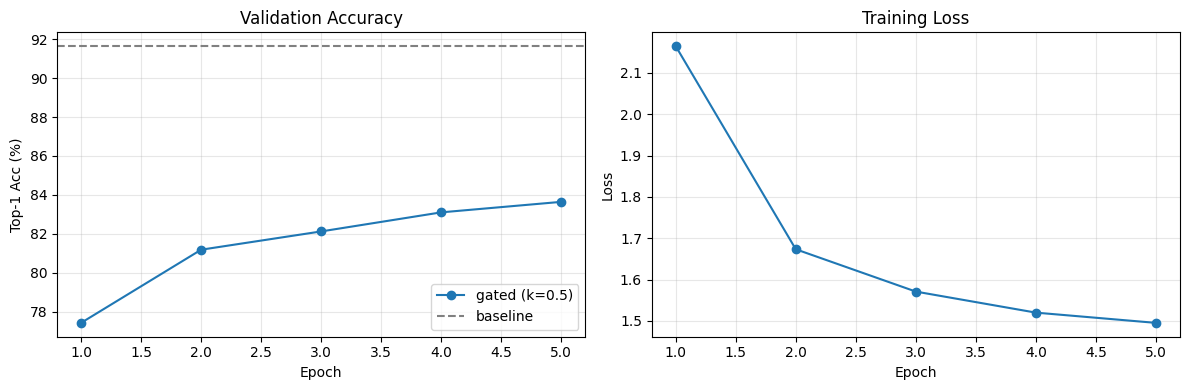

Summary saved.


In [ ]:
# Results summary
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['epoch'], history['val_acc'], marker='o', label=f'gated (k={CFG["keep_ratio"]})')
axes[0].axhline(baseline_acc, linestyle='--', color='grey', label='baseline')
axes[0].set_title('Validation Accuracy');
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Top-1 Acc (%)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history['epoch'], history['train_loss'], marker='o')
axes[1].set_title('Training Loss')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'checkpoints/gated_{CFG["keep_ratio"]}_curves.png', dpi=150)
plt.show()

summary = {
    'keep_ratio'   : CFG['keep_ratio'],
    'baseline_acc' : baseline_acc,
    'best_val_acc' : best_acc,
    'zero_shot_acc': zero_shot_acc,
    'throughput'   : throughput,
    'baseline_tput': 308,
}

with open(CFG['checkpoint_dir'] / f'gated_{CFG["keep_ratio"]}_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
print('Summary saved.')